# GitHub User Churn Predictor — EDA and Feature Selection

This notebook collects public GitHub user data, generates churn-related features, creates a churn label, applies four feature selection methods, and compares which features are most useful for predicting user churn.

The churn definition used in this project is:

> A GitHub user is considered churned if they have been inactive for more than 180 days.

In [1]:
import sys
import os

# Allow notebook to import files from the app folder
sys.path.append("../app")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scraper import fetch_github_users
from features import generate_features

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
raw_df = fetch_github_users(sleep_time=1)

print("Raw data shape:", raw_df.shape)

if raw_df.empty:
    print("No data was fetched. GitHub may be blocking requests due to rate limits or connection timeout.")
else:
    display(raw_df.head())

Error fetching tiangolo: HTTPSConnectionPool(host='api.github.com', port=443): Max retries exceeded with url: /users/tiangolo (Caused by ConnectTimeoutError(<HTTPSConnection(host='api.github.com', port=443) at 0x1820255fb10>, 'Connection to api.github.com timed out. (connect timeout=10)'))
Raw data shape: (39, 7)


,username,public_repos,public_gists,followers,following,created_at,updated_at
0,torvalds,12,1,306309,0,2011-09-03T15:26:22Z,2026-06-02T05:33:59Z
1,gaearon,296,82,90810,174,2011-05-25T18:18:31Z,2026-06-09T16:41:43Z
2,sindresorhus,1134,99,79729,31,2009-12-20T22:57:02Z,2026-05-28T18:00:42Z
3,tj,296,551,51769,45,2008-09-18T22:37:28Z,2026-04-02T08:29:42Z
4,yyx990803,198,73,108187,100,2010-11-28T01:05:40Z,2026-04-24T09:28:14Z


In [4]:
import os

os.makedirs("../data/raw", exist_ok=True)
print("Folder data/raw is ready.")

Folder data/raw is ready.


In [5]:
raw_df.to_csv("../data/raw/github_users.csv", index=False)
print("Saved GitHub data to data/raw/github_users.csv")

Saved GitHub data to data/raw/github_users.csv


In [6]:
if raw_df.empty:
    print("Cannot inspect data because raw_df is empty.")
else:
    print("Missing values:")
    print(raw_df.isnull().sum())

    print("\nData types:")
    print(raw_df.dtypes)

    display(raw_df.describe())

Missing values:
username        0
public_repos    0
public_gists    0
followers       0
following       0
created_at      0
updated_at      0
dtype: int64

Data types:
username          str
public_repos    int64
public_gists    int64
followers       int64
following       int64
created_at        str
updated_at        str
dtype: object


,public_repos,public_gists,followers,following
count,39.000000,39.000000,39.000000,39.000000
mean,561.410256,59.076923,37400.333333,29.051282
std,1440.743553,126.848103,55399.132992,68.679250
min,8.000000,0.000000,1574.000000,0.000000
25%,48.000000,0.000000,8972.000000,0.000000
50%,107.000000,0.000000,17393.000000,0.000000
75%,248.500000,41.500000,40463.500000,10.000000
max,8024.000000,551.000000,306309.000000,266.000000


In [7]:
df, feature_cols = generate_features(raw_df)

print("Generated features:")
print(feature_cols)

print("\nDataset shape after feature generation:", df.shape)

df.head()

Generated features:
['days_since_last_activity', 'account_age_days', 'repos_per_year', 'gists_per_year', 'follower_ratio', 'following_ratio', 'followers_per_repo', 'has_no_repos', 'is_new_account', 'high_following_low_followers', 'public_repos', 'public_gists', 'degree_centrality', 'betweenness_centrality', 'pagerank']

Dataset shape after feature generation: (39, 22)


,username,public_repos,public_gists,followers,following,created_at,updated_at,days_since_last_activity,account_age_days,account_age_years,...,follower_ratio,following_ratio,followers_per_repo,has_no_repos,is_new_account,high_following_low_followers,degree_centrality,betweenness_centrality,pagerank,churned
0,torvalds,12,1,306309,0,2011-09-03 15:26:22+00:00,2026-06-02 05:33:59+00:00,7,5393,14.765229,...,306309.000000,0.000000,23562.230769,0,0,0,0.0,0.0,0.025641,0
1,gaearon,296,82,90810,174,2011-05-25 18:18:31+00:00,2026-06-09 16:41:43+00:00,0,5494,15.041752,...,518.914286,0.001916,305.757576,0,0,0,0.0,0.0,0.025641,0
2,sindresorhus,1134,99,79729,31,2009-12-20 22:57:02+00:00,2026-05-28 18:00:42+00:00,12,6014,16.465435,...,2491.531250,0.000389,70.245815,0,0,0,0.0,0.0,0.025641,0
3,tj,296,551,51769,45,2008-09-18 22:37:28+00:00,2026-04-02 08:29:42+00:00,68,6472,17.719370,...,1125.413043,0.000869,174.306397,0,0,0,0.0,0.0,0.025641,0
4,yyx990803,198,73,108187,100,2010-11-28 01:05:40+00:00,2026-04-24 09:28:14+00:00,46,5672,15.529090,...,1071.158416,0.000924,543.653266,0,0,0,0.0,0.0,0.025641,0


Class balance:
churned
0    29
1    10
Name: count, dtype: int64

Class balance (%):
churned
0    74.358974
1    25.641026
Name: proportion, dtype: float64


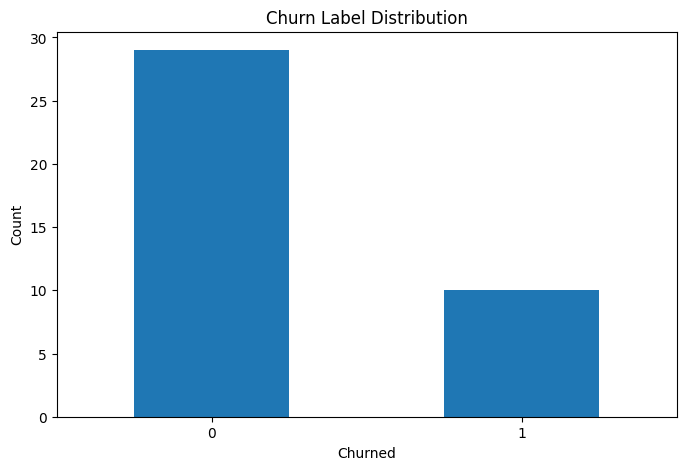

In [8]:
print("Class balance:")
print(df["churned"].value_counts())

print("\nClass balance (%):")
print(df["churned"].value_counts(normalize=True) * 100)

df["churned"].value_counts().plot(kind="bar")
plt.title("Churn Label Distribution")
plt.xlabel("Churned")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

The churn label is based on inactivity. Users with more than 180 days since their last public GitHub activity are labeled as churned. This threshold is reasonable for GitHub because developers may naturally have pauses, but long inactivity can still indicate disengagement.

In [9]:
df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
days_since_last_activity,39.0,117.769231,176.284827,0.000000,15.000000,32.000000,136.500000,679.000000
account_age_days,39.0,5179.641026,1307.390963,880.000000,4095.500000,5614.000000,6115.000000,6807.000000
repos_per_year,39.0,36.961064,101.708211,0.411941,3.244345,8.329461,18.090157,594.566313
gists_per_year,39.0,3.236029,6.891368,0.000000,0.000000,0.000000,2.119361,29.434751
follower_ratio,39.0,23658.002601,54484.890995,105.134259,2083.333333,5495.000000,16261.500000,306309.000000
following_ratio,39.0,0.000819,0.002105,0.000000,0.000000,0.000000,0.000391,0.009467
followers_per_repo,39.0,862.389249,3754.204797,4.132053,69.616442,174.306397,308.887097,23562.230769
has_no_repos,39.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
is_new_account,39.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
high_following_low_followers,39.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [10]:
corr_with_churn = df[feature_cols + ["churned"]].corr()["churned"].sort_values(ascending=False)

print(corr_with_churn)

churned                         1.000000
days_since_last_activity        0.880208
repos_per_year                  0.271392
public_repos                    0.247411
follower_ratio                  0.054186
following_ratio                 0.036125
followers_per_repo             -0.109402
public_gists                   -0.148560
gists_per_year                 -0.158896
account_age_days               -0.246461
has_no_repos                         NaN
is_new_account                       NaN
high_following_low_followers         NaN
degree_centrality                    NaN
betweenness_centrality               NaN
pagerank                             NaN
Name: churned, dtype: float64


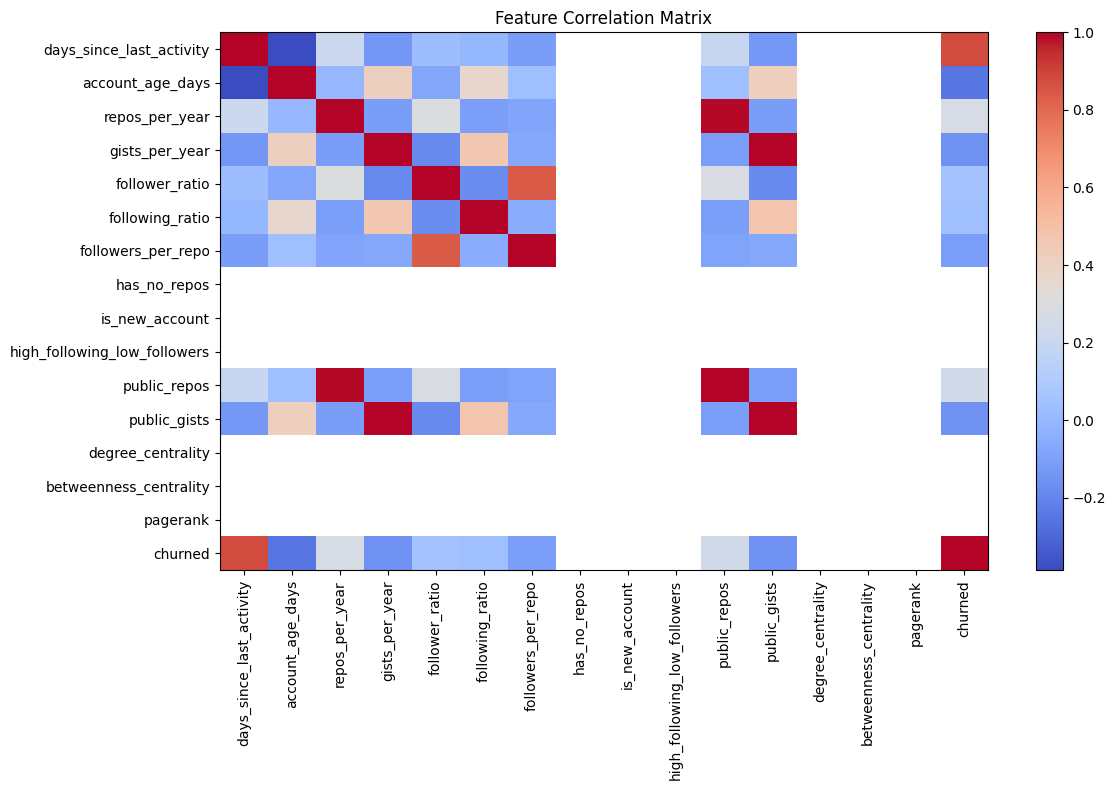

In [11]:
corr = df[feature_cols + ["churned"]].corr()

plt.figure(figsize=(12, 8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [12]:
X = df[feature_cols]
y = df["churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (29, 15)
Test shape: (10, 15)


In [14]:
# Variance Threshold
var_selector = VarianceThreshold(threshold=0.01)
var_selector.fit(X_train)

variance_kept = X.columns[var_selector.get_support()].tolist()

print("Features kept after Variance Threshold:")
print(variance_kept)

# ANOVA F-test
kbest = SelectKBest(score_func=f_classif, k=5)
kbest.fit(X_train, y_train)

filter_scores = pd.DataFrame({
    "Feature": X.columns,
    "ANOVA_Score": kbest.scores_,
    "Selected_Filter": kbest.get_support()
}).sort_values("ANOVA_Score", ascending=False)

filter_scores

Features kept after Variance Threshold:
['days_since_last_activity', 'account_age_days', 'repos_per_year', 'gists_per_year', 'follower_ratio', 'followers_per_repo', 'public_repos', 'public_gists']


c:\Users\JAVIER\Desktop\churn-predictor\venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 7  8  9 12 13] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\JAVIER\Desktop\churn-predictor\venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,Feature,ANOVA_Score,Selected_Filter
0,days_since_last_activity,244.180124,True
2,repos_per_year,3.602757,True
10,public_repos,3.033161,True
5,following_ratio,0.598407,True
6,followers_per_repo,0.397575,True
4,follower_ratio,0.337882,False
3,gists_per_year,0.174956,False
1,account_age_days,0.161672,False
11,public_gists,0.125389,False
14,pagerank,-0.000000,False


In [15]:
log_model = LogisticRegression(max_iter=1000, class_weight="balanced")

rfe = RFE(
    estimator=log_model,
    n_features_to_select=5
)

rfe.fit(X_train, y_train)

rfe_results = pd.DataFrame({
    "Feature": X.columns,
    "RFE_Selected": rfe.support_,
    "RFE_Ranking": rfe.ranking_
}).sort_values("RFE_Ranking")

rfe_results

,Feature,RFE_Selected,RFE_Ranking
0,days_since_last_activity,True,1
1,account_age_days,True,1
2,repos_per_year,True,1
6,followers_per_repo,True,1
10,public_repos,True,1
11,public_gists,False,2
3,gists_per_year,False,3
4,follower_ratio,False,4
14,pagerank,False,5
5,following_ratio,False,6


In [16]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

dt.fit(X_train, y_train)

dt_results = pd.DataFrame({
    "Feature": X.columns,
    "DT_Importance": dt.feature_importances_
}).sort_values("DT_Importance", ascending=False)

dt_results

,Feature,DT_Importance
0,days_since_last_activity,1.000000e+00
5,following_ratio,1.887379e-15
1,account_age_days,0.000000e+00
2,repos_per_year,0.000000e+00
3,gists_per_year,0.000000e+00
4,follower_ratio,0.000000e+00
6,followers_per_repo,0.000000e+00
7,has_no_repos,0.000000e+00
8,is_new_account,0.000000e+00
9,high_following_low_followers,0.000000e+00


In [17]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

rf_results = pd.DataFrame({
    "Feature": X.columns,
    "RF_Importance": rf.feature_importances_
}).sort_values("RF_Importance", ascending=False)

rf_results

,Feature,RF_Importance
0,days_since_last_activity,0.399906
4,follower_ratio,0.143291
1,account_age_days,0.113161
6,followers_per_repo,0.095338
2,repos_per_year,0.094504
10,public_repos,0.080389
5,following_ratio,0.028624
3,gists_per_year,0.025690
11,public_gists,0.019097
8,is_new_account,0.000000


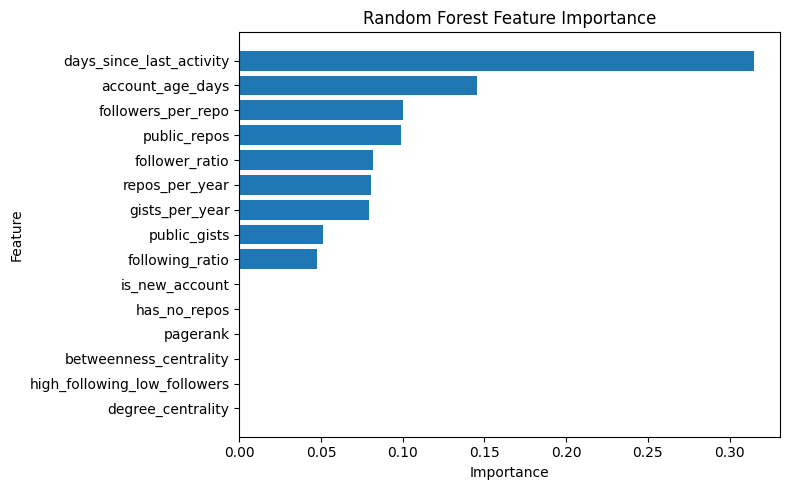

In [24]:
rf_results_sorted = rf_results.sort_values("RF_Importance", ascending=True)

plt.barh(rf_results_sorted["Feature"], rf_results_sorted["RF_Importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [18]:
comparison = pd.DataFrame({"Feature": X.columns})

comparison = comparison.merge(
    filter_scores[["Feature", "ANOVA_Score", "Selected_Filter"]],
    on="Feature"
)

comparison = comparison.merge(
    rfe_results[["Feature", "RFE_Selected", "RFE_Ranking"]],
    on="Feature"
)

comparison = comparison.merge(
    dt_results[["Feature", "DT_Importance"]],
    on="Feature"
)

comparison = comparison.merge(
    rf_results[["Feature", "RF_Importance"]],
    on="Feature"
)

comparison["RF_Rank"] = comparison["RF_Importance"].rank(ascending=False).astype(int)
comparison["DT_Rank"] = comparison["DT_Importance"].rank(ascending=False).astype(int)

comparison = comparison.sort_values("RF_Importance", ascending=False)

comparison

,Feature,ANOVA_Score,Selected_Filter,RFE_Selected,RFE_Ranking,DT_Importance,RF_Importance,RF_Rank,DT_Rank
0,days_since_last_activity,244.180124,True,True,1,1.000000e+00,0.399906,1,1
4,follower_ratio,0.337882,False,False,4,0.000000e+00,0.143291,2,9
1,account_age_days,0.161672,False,True,1,0.000000e+00,0.113161,3,9
6,followers_per_repo,0.397575,True,True,1,0.000000e+00,0.095338,4,9
2,repos_per_year,3.602757,True,True,1,0.000000e+00,0.094504,5,9
10,public_repos,3.033161,True,True,1,0.000000e+00,0.080389,6,9
5,following_ratio,0.598407,True,False,6,1.887379e-15,0.028624,7,2
3,gists_per_year,0.174956,False,False,3,0.000000e+00,0.025690,8,9
11,public_gists,0.125389,False,False,2,0.000000e+00,0.019097,9,9
8,is_new_account,NaN,False,False,10,0.000000e+00,0.000000,12,9


In [19]:
final_features = [
    "days_since_last_activity",
    "account_age_days",
    "repos_per_year",
    "follower_ratio",
    "followers_per_repo",
    "public_repos",
]

print("Final selected features:")
for f in final_features:
    print("-", f)

Final selected features:
- days_since_last_activity
- account_age_days
- repos_per_year
- follower_ratio
- followers_per_repo
- public_repos


The final features were selected because they appeared consistently across the feature selection methods and also make business sense.

- `days_since_last_activity` is a direct recency signal.
- `account_age_days` gives context about how long the user has been registered.
- `repos_per_year` measures normalized productivity.
- `follower_ratio` captures social engagement.
- `followers_per_repo` measures influence relative to repository activity.
- `public_repos` captures overall contribution volume.

In [20]:
X_final = X[final_features]

rf_final = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    class_weight="balanced"
)

cv_accuracy = cross_val_score(rf_final, X_final, y, cv=5, scoring="accuracy")
cv_precision = cross_val_score(rf_final, X_final, y, cv=5, scoring="precision")
cv_recall = cross_val_score(rf_final, X_final, y, cv=5, scoring="recall")
cv_f1 = cross_val_score(rf_final, X_final, y, cv=5, scoring="f1")

print(f"CV Accuracy : {cv_accuracy.mean():.3f} ± {cv_accuracy.std():.3f}")
print(f"CV Precision: {cv_precision.mean():.3f} ± {cv_precision.std():.3f}")
print(f"CV Recall   : {cv_recall.mean():.3f} ± {cv_recall.std():.3f}")
print(f"CV F1       : {cv_f1.mean():.3f} ± {cv_f1.std():.3f}")

CV Accuracy : 1.000 ± 0.000
CV Precision: 1.000 ± 0.000
CV Recall   : 1.000 ± 0.000
CV F1       : 1.000 ± 0.000


## Interpretation

The most important churn predictor is `days_since_last_activity`, which is expected because churn was defined based on inactivity. However, the model also uses other useful signals such as account age, repository productivity, and social engagement.

The Random Forest importance ranking is more stable than a single Decision Tree because it averages importance across many trees. The Decision Tree is easier to interpret but more sensitive to the specific train/test split.

From a retention perspective, users with long inactivity, low repository activity, and weak social engagement may be at higher risk of churn. A platform could respond by sending re-engagement messages, recommending repositories to contribute to, or suggesting communities/users to follow.

# PCA Dimensionality Reduction

In this section, PCA is applied to the engineered feature matrix. Unlike feature selection methods, PCA does not select existing features. Instead, it creates new compressed components that summarize the information contained in the original features.

The goal is to check whether users can be represented in a lower-dimensional space while still preserving most of the variance.

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# Use all engineered features
X_all = df[feature_cols]
y = df["churned"]

# Standardize before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

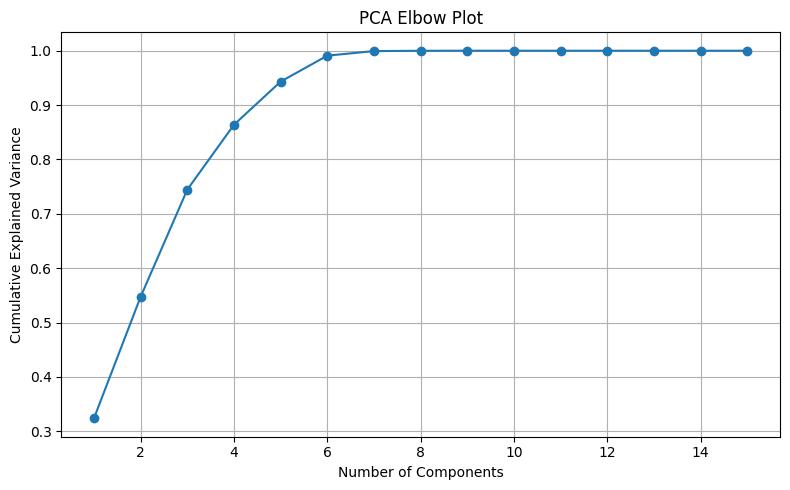

1 components: 0.324 cumulative variance
2 components: 0.547 cumulative variance
3 components: 0.744 cumulative variance
4 components: 0.864 cumulative variance
5 components: 0.943 cumulative variance
6 components: 0.991 cumulative variance
7 components: 0.999 cumulative variance
8 components: 1.000 cumulative variance
9 components: 1.000 cumulative variance
10 components: 1.000 cumulative variance
11 components: 1.000 cumulative variance
12 components: 1.000 cumulative variance
13 components: 1.000 cumulative variance
14 components: 1.000 cumulative variance
15 components: 1.000 cumulative variance


In [22]:
pca = PCA()
pca.fit(X_scaled)

cumulative_variance = pca.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Elbow Plot")
plt.grid(True)
plt.tight_layout()
plt.show()

for i, var in enumerate(cumulative_variance, start=1):
    print(f"{i} components: {var:.3f} cumulative variance")

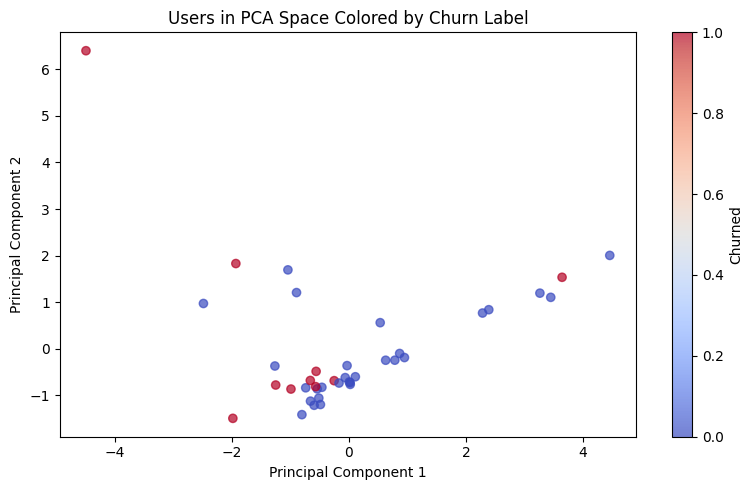

Variance explained by PC1 and PC2:
[0.32377018 0.22352559]
Total variance explained by 2 components:
0.5472957690486413


In [23]:
pca2 = PCA(n_components=2)
X_pca_2d = pca2.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=y,
    cmap="coolwarm",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Users in PCA Space Colored by Churn Label")
plt.colorbar(label="Churned")
plt.tight_layout()
plt.show()

print("Variance explained by PC1 and PC2:")
print(pca2.explained_variance_ratio_)
print("Total variance explained by 2 components:")
print(pca2.explained_variance_ratio_.sum())

In [24]:
# Original selected features
original_features = [
    "days_since_last_activity",
    "account_age_days",
    "repos_per_year",
    "follower_ratio",
    "followers_per_repo",
    "public_repos"
]

X_original = df[original_features]

rf_original = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    class_weight="balanced"
)

original_f1 = cross_val_score(
    rf_original,
    X_original,
    y,
    cv=5,
    scoring="f1"
)

# PCA model using first 2 components
rf_pca = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    class_weight="balanced"
)

pca_f1 = cross_val_score(
    rf_pca,
    X_pca_2d,
    y,
    cv=5,
    scoring="f1"
)

print(f"Original selected features CV F1: {original_f1.mean():.3f} ± {original_f1.std():.3f}")
print(f"PCA 2-component CV F1          : {pca_f1.mean():.3f} ± {pca_f1.std():.3f}")

Original selected features CV F1: 1.000 ± 0.000
PCA 2-component CV F1          : 0.280 ± 0.254


## PCA Interpretation

The PCA elbow plot shows how much variance is preserved as more components are added. The 2D PCA scatter plot allows us to visually inspect whether churned and retained users separate in compressed feature space.

PCA is useful for visualization and dimensionality reduction, but it may lose interpretability because principal components are combinations of original features. In this project, the original engineered features are easier to explain from a churn and retention perspective.

# SVD Recommendation Engine

The original churn model predicts which users are at risk. The upgraded system also recommends repositories to re-engage high-risk users.

The recommender uses a user-repository interaction matrix based on starred repositories. SVD is applied to this matrix to estimate user preferences and recommend repositories the user has not already interacted with.

If the user has no public starred repositories or the matrix is too sparse, the system uses a fallback recommendation list of popular programming repositories. This is similar to real-world recommender systems, where cold-start users receive popular or default recommendations until more behavioral data is available.

In [25]:
from scraper import fetch_user_repo_interactions

interactions_df = fetch_user_repo_interactions(max_repos=10)

print("Interactions shape:", interactions_df.shape)
interactions_df.head()

Error fetching starred repos for spring-projects: HTTPSConnectionPool(host='api.github.com', port=443): Read timed out. (read timeout=10)
Interactions shape: (115, 3)


,username,repo,interaction
0,torvalds,torvalds/linux,1
1,torvalds,subsurface/subsurface,1
2,gaearon,dollspace-gay/chainlink,1
3,gaearon,WinterTC55/iter-streams,1
4,gaearon,gamesgamesgamesgamesgames/happyview,1


In [26]:
if not interactions_df.empty:
    user_item_matrix = interactions_df.pivot_table(
        index="username",
        columns="repo",
        values="interaction",
        fill_value=0
    )

    print("User-item matrix shape:", user_item_matrix.shape)
    display(user_item_matrix.head())
else:
    print("No starred repository interactions were collected.")

User-item matrix shape: (13, 112)


repo,BeehiveInnovations/pal-mcp-server,CGCookie/retopoflow,ChartGPU/ChartGPU,ChromeDevTools/chrome-devtools-mcp,DamageLabs/clahub,Dokploy/dokploy,GoogleCloudPlatform/agent-starter-pack,HarryStevens/geometric,KeygraphHQ/shannon,Krowemoh/vlc.js,...,swiftlang/swift,tornadoweb/tornado,torvalds/linux,treethought/obsidian-atmosphere,ts-macro/ts-macro,ubugeeei-prod/vize,violet-org/boysenberry-repo,vitejs/devtools,vuejs/devtools,zumerlab/snapdom
username,,,,,,,,,,,,,,,,,,,,,
addyosmani,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
defunkt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
gaearon,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
getify,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
kennethreitz,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
from scipy.sparse.linalg import svds
import numpy as np

if not interactions_df.empty and min(user_item_matrix.shape) > 2:
    matrix_values = user_item_matrix.values.astype(float)
    
    k = min(5, min(matrix_values.shape) - 1)
    
    U, sigma, Vt = svds(matrix_values, k=k)
    sigma_diag = np.diag(sigma)
    
    predicted_scores = np.dot(np.dot(U, sigma_diag), Vt)
    
    print("SVD completed successfully.")
    print("U shape:", U.shape)
    print("Sigma shape:", sigma_diag.shape)
    print("Vt shape:", Vt.shape)
    print("Predicted score matrix shape:", predicted_scores.shape)
else:
    print("Not enough interaction data for meaningful SVD. The API uses fallback recommendations if needed.")

SVD completed successfully.
U shape: (13, 5)
Sigma shape: (5, 5)
Vt shape: (5, 112)
Predicted score matrix shape: (13, 112)


## SVD Interpretation

SVD decomposes the user-repository interaction matrix into latent user and repository factors. Users that are close in this latent space are assumed to have similar interests. Therefore, repositories liked by similar users can be recommended to a high-risk user.

In this project, the recommendation endpoint first checks churn probability. If the user is not high risk, it returns no recommendation. If the user is high risk, it returns repository recommendations for re-engagement.

# Network Analysis

Network analysis adds structural information to the churn model. The idea is that users who are more isolated in a network may be more likely to churn, while users who are more connected may be more engaged.

Because unauthenticated GitHub API access does not efficiently provide full follower relationships, this project builds a proxy user network. Users are connected when they have similar public repository and follower patterns. From this network, degree centrality, betweenness centrality, and PageRank are computed and added as features.

In [28]:
import networkx as nx

G = nx.Graph()

for username in df["username"]:
    G.add_node(username)

for i in range(len(df)):
    for j in range(i + 1, len(df)):
        u1 = df.iloc[i]
        u2 = df.iloc[j]

        repos_close = abs(u1["public_repos"] - u2["public_repos"]) <= 10
        followers_close = abs(u1["followers"] - u2["followers"]) <= 50

        if repos_close and followers_close:
            G.add_edge(u1["username"], u2["username"])

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 39
Number of edges: 0


In [29]:
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
pagerank = nx.pagerank(G)

df["degree_centrality"] = df["username"].map(degree_centrality).fillna(0)
df["betweenness_centrality"] = df["username"].map(betweenness_centrality).fillna(0)
df["pagerank"] = df["username"].map(pagerank).fillna(0)

df[[
    "username",
    "churned",
    "degree_centrality",
    "betweenness_centrality",
    "pagerank"
]].head()

,username,churned,degree_centrality,betweenness_centrality,pagerank
0,torvalds,0,0.0,0.0,0.025641
1,gaearon,0,0.0,0.0,0.025641
2,sindresorhus,0,0.0,0.0,0.025641
3,tj,0,0.0,0.0,0.025641
4,yyx990803,0,0.0,0.0,0.025641


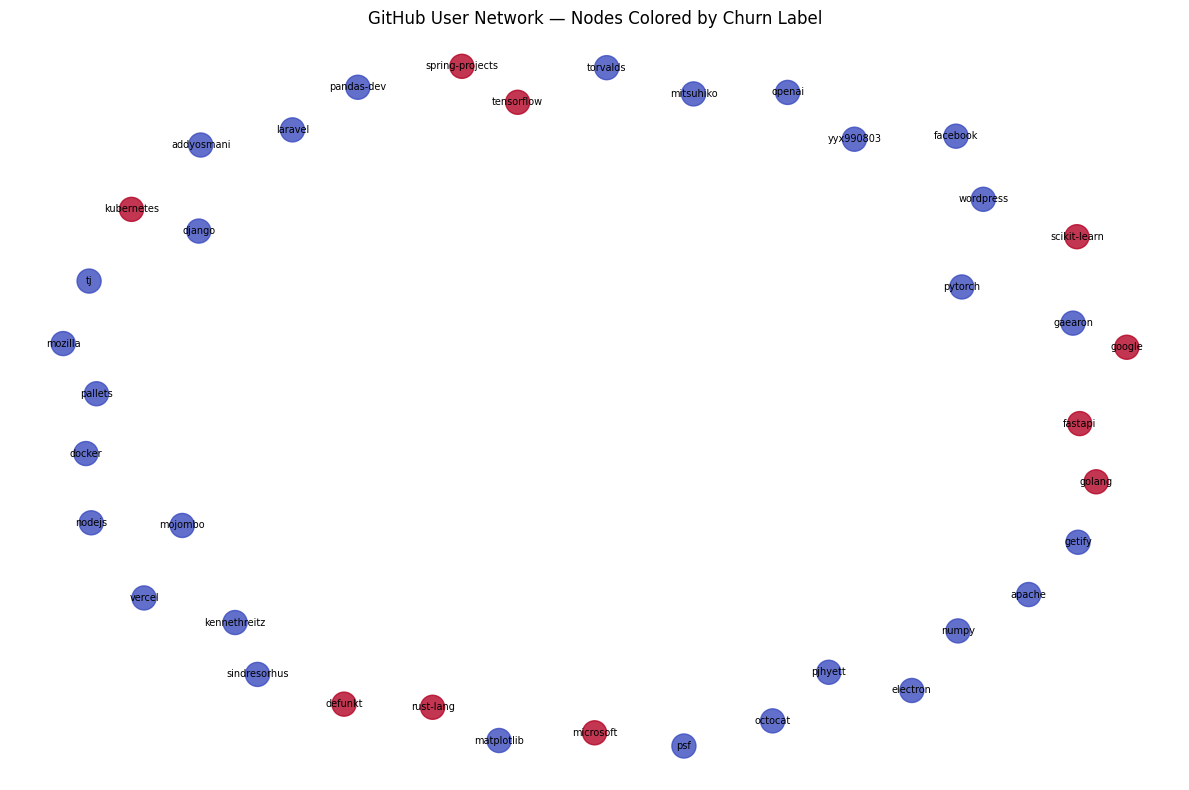

In [30]:
plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G, seed=42)

node_colors = df.set_index("username").loc[list(G.nodes), "churned"]

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    cmap="coolwarm",
    node_size=300,
    alpha=0.8
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.3
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=7
)

plt.title("GitHub User Network — Nodes Colored by Churn Label")
plt.axis("off")
plt.tight_layout()
plt.show()

# Updated Feature Selection with Network Features

After adding network centrality metrics, the feature selection methods are repeated. This allows us to check whether structural network features improve the churn model.

In [31]:
updated_feature_cols = feature_cols.copy()

for col in ["degree_centrality", "betweenness_centrality", "pagerank"]:
    if col not in updated_feature_cols:
        updated_feature_cols.append(col)

X_updated = df[updated_feature_cols]
y = df["churned"]

print("Updated features:")
print(updated_feature_cols)

Updated features:
['days_since_last_activity', 'account_age_days', 'repos_per_year', 'gists_per_year', 'follower_ratio', 'following_ratio', 'followers_per_repo', 'has_no_repos', 'is_new_account', 'high_following_low_followers', 'public_repos', 'public_gists', 'degree_centrality', 'betweenness_centrality', 'pagerank']


In [32]:
from sklearn.model_selection import train_test_split

X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_updated,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [33]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

var_selector_u = VarianceThreshold(threshold=0.01)
var_selector_u.fit(X_train_u)

variance_kept_u = X_updated.columns[var_selector_u.get_support()].tolist()

kbest_u = SelectKBest(score_func=f_classif, k=5)
kbest_u.fit(X_train_u, y_train_u)

filter_scores_u = pd.DataFrame({
    "Feature": X_updated.columns,
    "ANOVA_Score": kbest_u.scores_,
    "Selected_Filter": kbest_u.get_support()
}).sort_values("ANOVA_Score", ascending=False)

filter_scores_u

c:\Users\JAVIER\Desktop\churn-predictor\venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 7  8  9 12 13] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\JAVIER\Desktop\churn-predictor\venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,Feature,ANOVA_Score,Selected_Filter
0,days_since_last_activity,244.180124,True
2,repos_per_year,3.602757,True
10,public_repos,3.033161,True
5,following_ratio,0.598407,True
6,followers_per_repo,0.397575,True
4,follower_ratio,0.337882,False
3,gists_per_year,0.174956,False
1,account_age_days,0.161672,False
11,public_gists,0.125389,False
14,pagerank,-0.000000,False


In [34]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

log_model_u = LogisticRegression(max_iter=1000, class_weight="balanced")

rfe_u = RFE(
    estimator=log_model_u,
    n_features_to_select=5
)

rfe_u.fit(X_train_u, y_train_u)

rfe_results_u = pd.DataFrame({
    "Feature": X_updated.columns,
    "RFE_Selected": rfe_u.support_,
    "RFE_Ranking": rfe_u.ranking_
}).sort_values("RFE_Ranking")

rfe_results_u

,Feature,RFE_Selected,RFE_Ranking
0,days_since_last_activity,True,1
1,account_age_days,True,1
2,repos_per_year,True,1
6,followers_per_repo,True,1
10,public_repos,True,1
11,public_gists,False,2
3,gists_per_year,False,3
4,follower_ratio,False,4
14,pagerank,False,5
5,following_ratio,False,6


In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dt_u = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

dt_u.fit(X_train_u, y_train_u)

dt_results_u = pd.DataFrame({
    "Feature": X_updated.columns,
    "DT_Importance": dt_u.feature_importances_
}).sort_values("DT_Importance", ascending=False)

rf_u = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_u.fit(X_train_u, y_train_u)

rf_results_u = pd.DataFrame({
    "Feature": X_updated.columns,
    "RF_Importance": rf_u.feature_importances_
}).sort_values("RF_Importance", ascending=False)

display(dt_results_u)
display(rf_results_u)

,Feature,DT_Importance
0,days_since_last_activity,1.000000e+00
5,following_ratio,1.887379e-15
1,account_age_days,0.000000e+00
2,repos_per_year,0.000000e+00
3,gists_per_year,0.000000e+00
4,follower_ratio,0.000000e+00
6,followers_per_repo,0.000000e+00
7,has_no_repos,0.000000e+00
8,is_new_account,0.000000e+00
9,high_following_low_followers,0.000000e+00


,Feature,RF_Importance
0,days_since_last_activity,0.399906
4,follower_ratio,0.143291
1,account_age_days,0.113161
6,followers_per_repo,0.095338
2,repos_per_year,0.094504
10,public_repos,0.080389
5,following_ratio,0.028624
3,gists_per_year,0.025690
11,public_gists,0.019097
8,is_new_account,0.000000


In [36]:
comparison_u = pd.DataFrame({"Feature": X_updated.columns})

comparison_u = comparison_u.merge(
    filter_scores_u[["Feature", "ANOVA_Score", "Selected_Filter"]],
    on="Feature"
)

comparison_u = comparison_u.merge(
    rfe_results_u[["Feature", "RFE_Selected", "RFE_Ranking"]],
    on="Feature"
)

comparison_u = comparison_u.merge(
    dt_results_u[["Feature", "DT_Importance"]],
    on="Feature"
)

comparison_u = comparison_u.merge(
    rf_results_u[["Feature", "RF_Importance"]],
    on="Feature"
)

comparison_u["RF_Rank"] = comparison_u["RF_Importance"].rank(ascending=False).astype(int)
comparison_u["DT_Rank"] = comparison_u["DT_Importance"].rank(ascending=False).astype(int)

comparison_u = comparison_u.sort_values("RF_Importance", ascending=False)

comparison_u

,Feature,ANOVA_Score,Selected_Filter,RFE_Selected,RFE_Ranking,DT_Importance,RF_Importance,RF_Rank,DT_Rank
0,days_since_last_activity,244.180124,True,True,1,1.000000e+00,0.399906,1,1
4,follower_ratio,0.337882,False,False,4,0.000000e+00,0.143291,2,9
1,account_age_days,0.161672,False,True,1,0.000000e+00,0.113161,3,9
6,followers_per_repo,0.397575,True,True,1,0.000000e+00,0.095338,4,9
2,repos_per_year,3.602757,True,True,1,0.000000e+00,0.094504,5,9
10,public_repos,3.033161,True,True,1,0.000000e+00,0.080389,6,9
5,following_ratio,0.598407,True,False,6,1.887379e-15,0.028624,7,2
3,gists_per_year,0.174956,False,False,3,0.000000e+00,0.025690,8,9
11,public_gists,0.125389,False,False,2,0.000000e+00,0.019097,9,9
8,is_new_account,NaN,False,False,10,0.000000e+00,0.000000,12,9


In [37]:
comparison_u = pd.DataFrame({"Feature": X_updated.columns})

comparison_u = comparison_u.merge(
    filter_scores_u[["Feature", "ANOVA_Score", "Selected_Filter"]],
    on="Feature"
)

comparison_u = comparison_u.merge(
    rfe_results_u[["Feature", "RFE_Selected", "RFE_Ranking"]],
    on="Feature"
)

comparison_u = comparison_u.merge(
    dt_results_u[["Feature", "DT_Importance"]],
    on="Feature"
)

comparison_u = comparison_u.merge(
    rf_results_u[["Feature", "RF_Importance"]],
    on="Feature"
)

comparison_u["RF_Rank"] = comparison_u["RF_Importance"].rank(ascending=False).astype(int)
comparison_u["DT_Rank"] = comparison_u["DT_Importance"].rank(ascending=False).astype(int)

comparison_u = comparison_u.sort_values("RF_Importance", ascending=False)

comparison_u

,Feature,ANOVA_Score,Selected_Filter,RFE_Selected,RFE_Ranking,DT_Importance,RF_Importance,RF_Rank,DT_Rank
0,days_since_last_activity,244.180124,True,True,1,1.000000e+00,0.399906,1,1
4,follower_ratio,0.337882,False,False,4,0.000000e+00,0.143291,2,9
1,account_age_days,0.161672,False,True,1,0.000000e+00,0.113161,3,9
6,followers_per_repo,0.397575,True,True,1,0.000000e+00,0.095338,4,9
2,repos_per_year,3.602757,True,True,1,0.000000e+00,0.094504,5,9
10,public_repos,3.033161,True,True,1,0.000000e+00,0.080389,6,9
5,following_ratio,0.598407,True,False,6,1.887379e-15,0.028624,7,2
3,gists_per_year,0.174956,False,False,3,0.000000e+00,0.025690,8,9
11,public_gists,0.125389,False,False,2,0.000000e+00,0.019097,9,9
8,is_new_account,NaN,False,False,10,0.000000e+00,0.000000,12,9


In [38]:
from sklearn.model_selection import cross_val_score

# Original selected features
X_original = df[[
    "days_since_last_activity",
    "account_age_days",
    "repos_per_year",
    "follower_ratio",
    "followers_per_repo",
    "public_repos"
]]

# PCA 2D features already created: X_pca_2d

# Original + network features
X_network = df[[
    "days_since_last_activity",
    "account_age_days",
    "repos_per_year",
    "follower_ratio",
    "followers_per_repo",
    "public_repos",
    "degree_centrality",
    "pagerank"
]]

rf_compare = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    class_weight="balanced"
)

original_f1 = cross_val_score(rf_compare, X_original, y, cv=5, scoring="f1")
pca_f1 = cross_val_score(rf_compare, X_pca_2d, y, cv=5, scoring="f1")
network_f1 = cross_val_score(rf_compare, X_network, y, cv=5, scoring="f1")

model_comparison = pd.DataFrame({
    "Model Setup": [
        "Original selected features",
        "PCA 2 components",
        "Original + network features"
    ],
    "Mean F1": [
        original_f1.mean(),
        pca_f1.mean(),
        network_f1.mean()
    ],
    "Std F1": [
        original_f1.std(),
        pca_f1.std(),
        network_f1.std()
    ]
})

model_comparison

,Model Setup,Mean F1,Std F1
0,Original selected features,1.00,0.000000
1,PCA 2 components,0.28,0.254384
2,Original + network features,0.80,0.400000


In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import pandas as pd

# Original selected features
X_original = df[[
    "days_since_last_activity",
    "account_age_days",
    "repos_per_year",
    "follower_ratio",
    "followers_per_repo",
    "public_repos"
]]

# PCA 2D features should already exist as X_pca_2d

# Original + network features
X_network = df[[
    "days_since_last_activity",
    "account_age_days",
    "repos_per_year",
    "follower_ratio",
    "followers_per_repo",
    "public_repos",
    "degree_centrality",
    "pagerank"
]]

rf_compare = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    class_weight="balanced"
)

original_f1 = cross_val_score(rf_compare, X_original, y, cv=5, scoring="f1")
pca_f1 = cross_val_score(rf_compare, X_pca_2d, y, cv=5, scoring="f1")
network_f1 = cross_val_score(rf_compare, X_network, y, cv=5, scoring="f1")

model_comparison = pd.DataFrame({
    "Model Setup": [
        "Original selected features",
        "PCA 2 components",
        "Original + network features"
    ],
    "Mean F1": [
        original_f1.mean(),
        pca_f1.mean(),
        network_f1.mean()
    ],
    "Std F1": [
        original_f1.std(),
        pca_f1.std(),
        network_f1.std()
    ]
})

display(model_comparison)

,Model Setup,Mean F1,Std F1
0,Original selected features,1.00,0.000000
1,PCA 2 components,0.28,0.254384
2,Original + network features,0.80,0.400000


## Final Add-On Interpretation

The upgraded system moves from prediction to retention. The churn model identifies high-risk users, and the recommendation engine suggests repositories to re-engage them.

PCA provides a compressed visualization of the users, but the original engineered features remain easier to interpret. Network features add structural information about user connectedness, which can help explain whether isolated users are more likely to churn.

The `/recommend` endpoint closes the retention loop: if a user is predicted to be high risk, the system returns personalized or fallback repository recommendations designed to bring the user back.